# Heisenberg Ladder Spectrum

**Model.** A two-leg Heisenberg ladder contains `2 * n_rungs` spins. Leg bonds couple spins along each chain, and rung bonds couple the two chains.

**Typical uses.** Quasi-one-dimensional spin-system benchmarks, rung-coupling studies, exact diagonalization examples beyond simple chains, and VQE/QPE reference spectra.

**Parameters.** `n_rungs` sets ladder length; `leg_coupling` sets same-leg exchange; `rung_coupling` sets inter-leg exchange; `field` adds `Z` fields; `periodic` wraps each leg.

**Useful plots.** Sorted spectra, density of states, and gap versus rung-coupling curves.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from quantum_lattice_models.models import heisenberg_ladder
from quantum_lattice_models.plotting import plot_density_of_states, plot_lattice_spectrum
from quantum_lattice_models.spectra import ground_energy, spectral_gap

In [2]:
H = heisenberg_ladder(n_rungs=3, leg_coupling=1.0, rung_coupling=0.7, field=0.1)
print("Heisenberg ladder summary")
print(f"  matrix shape:  {H.shape}")
print(f"  spin sites:    {H.n_sites}")
print(f"  ground energy: {ground_energy(H): .6f}")
print(f"  spectral gap:  {spectral_gap(H): .6f}")

Heisenberg ladder summary
  matrix shape:  (64, 64)
  spin sites:    6
  ground energy: -10.811242
  spectral gap:   2.236184


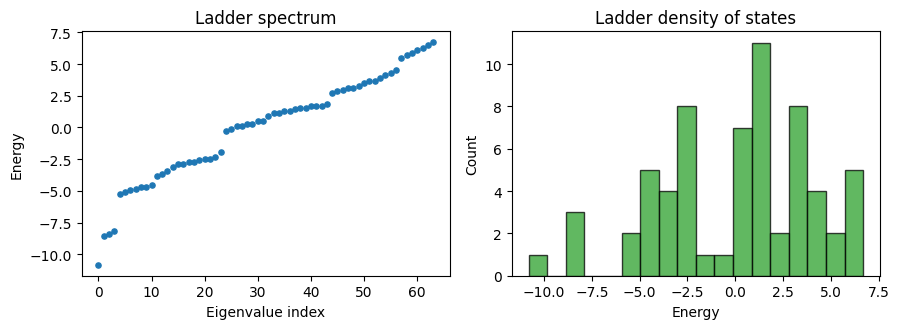

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
plot_lattice_spectrum(H, ax=axes[0], s=14, color="tab:blue")
axes[0].set_title("Ladder spectrum")
plot_density_of_states(H, bins=18, ax=axes[1], color="tab:green")
axes[1].set_title("Ladder density of states")
fig.tight_layout()

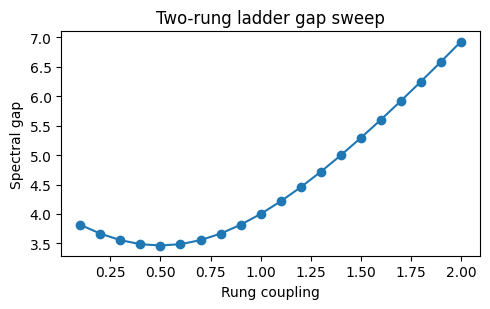

In [4]:
rungs = np.linspace(0.1, 2.0, 20)
gaps = [spectral_gap(heisenberg_ladder(n_rungs=2, rung_coupling=float(jr))) for jr in rungs]
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(rungs, gaps, marker="o")
ax.set_xlabel("Rung coupling")
ax.set_ylabel("Spectral gap")
ax.set_title("Two-rung ladder gap sweep")
fig.tight_layout()